可用变量数: 83


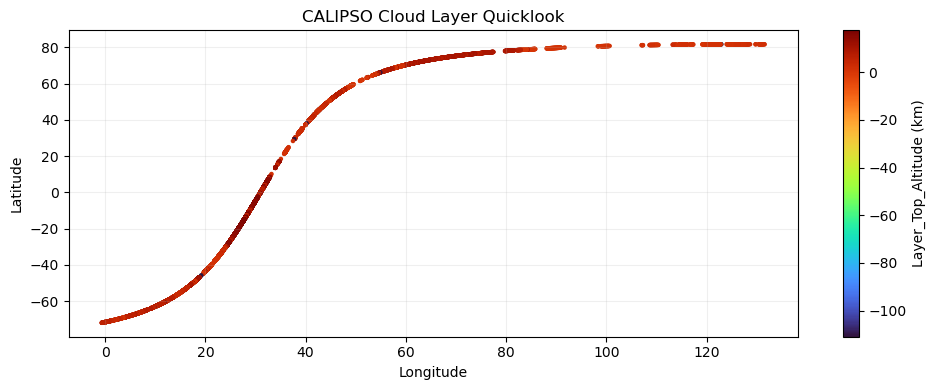

In [ ]:
# 可视化 CALIPSO HDF（按第一层云顶高度着色）
# 若未安装 pyhdf，请先在环境中安装：pip install pyhdf
from pyhdf.SD import SD, SDC
import numpy as np
import matplotlib.pyplot as plt

hdf_path = r"C:\Users\Cory Kong\Downloads\CAL_LID_L2_01kmCLay-Standard-V5-00.2023-02-17T00-45-48ZN.hdf"

hdf = SD(hdf_path, SDC.READ)
datasets = hdf.datasets()
print("可用变量数:", len(datasets))

lat = hdf.select('Latitude')[:].squeeze()
lon = hdf.select('Longitude')[:].squeeze()

# 常见云层顶高度变量名候选（不同产品版本可能不同）
alt_candidates = ['Layer_Top_Altitude', 'Layer_Top_Altitude_532', 'Layer_Base_Altitude']
alt_name = next((k for k in alt_candidates if k in datasets), None)
if alt_name is None:
    raise KeyError(f"未找到高度变量。可用变量示例: {list(datasets.keys())[:20]}")

alt = hdf.select(alt_name)[:]

# 填充值通常是很小的负值，这里统一转 NaN
alt = np.where(alt < -9000, np.nan, alt)

# 取第一层（第 0 列）做简单可视化
if alt.ndim == 2:
    alt_plot = alt[:, 0]
else:
    alt_plot = alt.squeeze()

plt.figure(figsize=(10, 4))
sc = plt.scatter(lon, lat, c=alt_plot, s=5, cmap='turbo')
plt.colorbar(sc, label=f'{alt_name} (km)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('CALIPSO Cloud Layer Quicklook')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()
